# TENSORFLOW
Dataset : ReviewTokoBaju.csv

In [7]:
# Instalasi dan Import Library
!pip install -q keras-tuner

Import Libraries

In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
from keras_tuner.tuners import RandomSearch


Load Dataset

In [9]:
url = "https://raw.githubusercontent.com/farrelrassya/teachingMLDL/main/02.%20Deep%20Learning/07.%20Week%207/Datasets/ReviewTokoBaju.csv"
df = pd.read_csv(url)
df.head()


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [10]:
print(df.columns)

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')


In [11]:
# Hapus baris yang tidak ada teks ulasannya
df = df[df['Review Text'].notnull()]

# Rename kolom agar lebih simpel
df['Review'] = df['Review Text']
df['Label'] = df['Recommended IND']

# Hanya ambil kolom yang dipakai
df = df[['Review', 'Label']]


<ipython-input-11-8e532d56f5fc>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Review'] = df['Review Text']
<ipython-input-11-8e532d56f5fc>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Label'] = df['Recommended IND']


Preprocessing

In [12]:
# Mengecek null
df.isnull().sum()

# Label encoding
df['Label'].value_counts()

# Tokenizing & Padding
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(df['Review'])

sequences = tokenizer.texts_to_sequences(df['Review'])
padded = pad_sequences(sequences, padding='post', maxlen=100)

# Label to numpy array
labels = df['Label'].values

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(padded, labels, test_size=0.2, random_state=42)


Build Bidirectional RNN Model





In [13]:
def build_model(hp):
    model = tf.keras.Sequential()
    model.add(layers.Embedding(input_dim=10000, output_dim=hp.Int('embedding_dim', 16, 64, step=16), input_length=100))
    model.add(layers.Bidirectional(layers.LSTM(units=hp.Int('lstm_units', 32, 128, step=32), return_sequences=False)))
    model.add(layers.Dense(units=hp.Int('dense_units', 32, 128, step=32), activation='relu'))
    model.add(layers.Dropout(rate=hp.Float('dropout', 0.2, 0.5, step=0.1)))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp.Choice('lr', [1e-3, 1e-4])),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


Hyperparameter Tuning (Keras Tuner)

In [14]:
tuner = RandomSearch(build_model,
                     objective='val_accuracy',
                     max_trials=5,
                     directory='tuning_dir',
                     project_name='bidir_rnn')

tuner.search(X_train, y_train, epochs=5, validation_split=0.2, batch_size=32)

# Ambil model terbaik
best_model = tuner.get_best_models(num_models=1)[0]


Trial 5 Complete [00h 00m 46s]
val_accuracy: 0.8837979435920715

Best val_accuracy So Far: 0.8871101140975952
Total elapsed time: 00h 03m 54s


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [28]:
history = best_model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), batch_size=32)

Epoch 1/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 1.0000 - loss: 6.2555e-05 - val_accuracy: 0.8525 - val_loss: 2.3116
Epoch 2/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 1.0000 - loss: 5.0509e-05 - val_accuracy: 0.8527 - val_loss: 2.4188
Epoch 3/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 1.0000 - loss: 2.1770e-05 - val_accuracy: 0.8521 - val_loss: 2.5750
Epoch 4/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 1.0000 - loss: 1.1089e-05 - val_accuracy: 0.8532 - val_loss: 2.5979
Epoch 5/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 1.0000 - loss: 8.9603e-06 - val_accuracy: 0.8514 - val_loss: 2.4732
Epoch 6/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 1.0000 - loss: 1.1900e-05 - val_accuracy: 0.8510 - val_loss: 2.6381
Epoch 7/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 1.0000 - loss: 8.7475e-06 - val_accuracy: 0.8521 - val_loss: 2.6998
Epoch 8/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 1.

Evaluasi

In [33]:
# Evaluasi model
train_loss, train_acc = best_model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)

# Tampilkan dalam bentuk persen
# Output
print("="*60)
print(f"\n🎯 Akurasi Training Set  : {train_acc * 100:.2f}%")
print(f"🎯 Akurasi Testing Set   : {test_acc * 100:.2f}%")
# Output
print("="*60)

y_pred_prob = best_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"Akurasi: {acc:.4f}")
print(f"Presisi: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")



🎯 Akurasi Training Set  : 100.00%
🎯 Akurasi Testing Set   : 84.92%
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Akurasi: 0.8492
Presisi: 0.9109
Recall: 0.9048
F1-Score: 0.9078
AUC: 0.8331


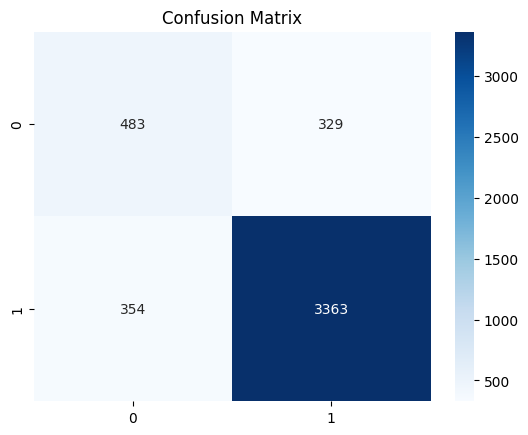

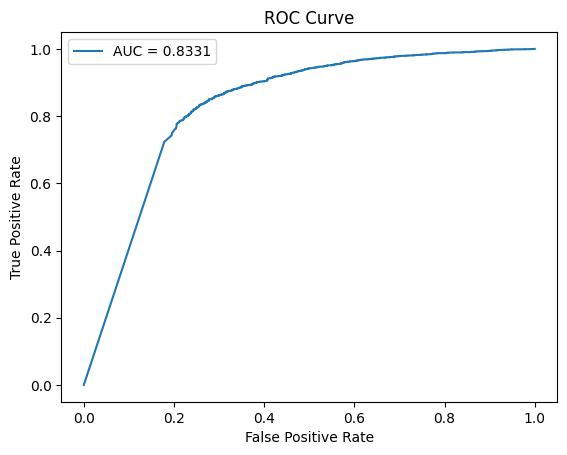

In [31]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


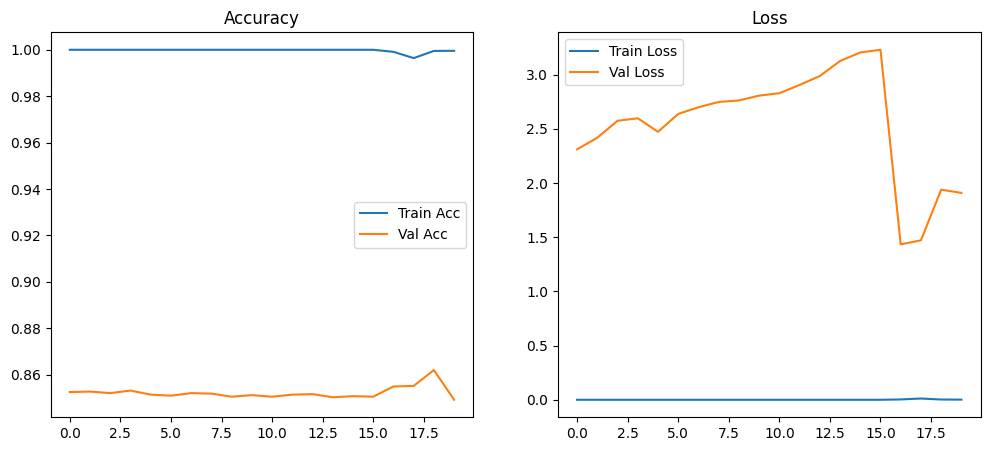

In [32]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()
